# Step 1: Get Features From Multiple Datasets
- Using [pybiber](https://pypi.org/project/pybiber/)

In [1]:
import pybiber as pb
import polars as pl
import os

In [2]:
FILE_PATH = 'getText/datasetsPrep'
OUTPUT_DIR = 'biberOutputs'

In [3]:
# Load all data.
list_of_dfs = []
for folder in os.listdir(f'./{FILE_PATH}'):
    if os.path.isdir(f'./{FILE_PATH}/{folder}'):
        for file in os.listdir(f'./{FILE_PATH}/{folder}'):
            if file.endswith(".csv"):
                temp_file_path = f'./{FILE_PATH}/{folder}/{file}'
                temp_tag = file.replace('.csv', '')
                temp_df = pl.read_csv(temp_file_path)
                temp_df = (
                    temp_df
                    .with_row_index("index_num") # , offset=1) if you want to start index from 1
                    .with_columns(
                        (pl.lit(temp_tag) + "_" + pl.col("index_num").cast(pl.Utf8)).alias("doc_id")
                    )).select(['text', 'doc_id'])
                list_of_dfs.append(temp_df)

combined = pl.concat(list_of_dfs, how="vertical")
assert combined.select(pl.col("doc_id").n_unique()).item() == combined.height, "There should be no duplicates in the dataset."

In [4]:
# Remove invalid data.
temp_df = combined.with_columns(
    pl.col("doc_id").str.split("_").list.get(0).alias("tag")
)
print(temp_df.group_by("tag").len())
print(f"Total Texts Before Empty String Removal: {len(temp_df)}")

temp_df = combined.with_columns(pl.col("text").str.strip_chars().alias("text")).filter(pl.col("text").is_not_null() & (pl.col("text") != ""))

temp_df = temp_df.with_columns(
    pl.col("doc_id").str.split("_").list.get(0).alias("tag")
)
print(temp_df.group_by("tag").len())
print(f"Total Texts After Empty String Removal: {len(temp_df)}")

shape: (14, 2)
┌────────────────────────────────┬────────┐
│ tag                            ┆ len    │
│ ---                            ┆ ---    │
│ str                            ┆ u32    │
╞════════════════════════════════╪════════╡
│ 20NewsGroups                   ┆ 18846  │
│ clinc150                       ┆ 23700  │
│ dementiaAudio                  ┆ 549    │
│ yahoo                          ┆ 87362  │
│ atis                           ┆ 4978   │
│ clinicalDialogueSummarizations ┆ 3603   │
│ medicalAbstracts               ┆ 14438  │
│ banking77                      ┆ 13069  │
│ bbcNews                        ┆ 2225   │
│ huffPostNews                   ┆ 209527 │
│ augmentedClinicalNotes         ┆ 30000  │
│ trumpTweets                    ┆ 56571  │
│ simSUM                         ┆ 10000  │
│ syntheticCareHomeNurseNotes    ┆ 5783   │
└────────────────────────────────┴────────┘
Total Texts Before Empty String Removal: 480651
shape: (14, 2)
┌────────────────────────────────┬────────

In [5]:
# TEST FIRST - ISABEL HERE REMOVE THIS

temp_df = temp_df.with_columns(
    pl.col("doc_id").str.split("_").list.get(0).alias("tag")
)

temp_df = temp_df.group_by("tag").head(50) 

[INFO] Using TTR for f_43_type_token


Performance: Corpus processing completed in 11.41s


[INFO] All features normalized per 1000 tokens except: f_43_type_token and f_44_mean_word_length


shape: (700, 69)
┌─────────┬─────────┬─────────┬─────────┬─────────┬───┬────────┬────────┬────────┬────────┬────────┐
│ doc_id  ┆ f_01_pa ┆ f_02_pe ┆ f_03_pr ┆ f_04_pl ┆ … ┆ f_64_p ┆ f_65_c ┆ f_66_n ┆ f_67_n ┆ catego │
│ ---     ┆ st_tens ┆ rfect_a ┆ esent_t ┆ ace_adv ┆   ┆ hrasal ┆ lausal ┆ eg_syn ┆ eg_ana ┆ ry     │
│ str     ┆ e       ┆ spect   ┆ ense    ┆ erbials ┆   ┆ _coord ┆ _coord ┆ thetic ┆ lytic  ┆ ---    │
│         ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆   ┆ inatio ┆ inatio ┆ ---    ┆ ---    ┆ str    │
│         ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆   ┆ n      ┆ n      ┆ f64    ┆ f64    ┆        │
│         ┆         ┆         ┆         ┆         ┆   ┆ ---    ┆ ---    ┆        ┆        ┆        │
│         ┆         ┆         ┆         ┆         ┆   ┆ f64    ┆ f64    ┆        ┆        ┆        │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═══╪════════╪════════╪════════╪════════╪════════╡
│ 20NewsG ┆ 5.00834 ┆ 4.17362 ┆ 67.6126 ┆ 4.17362 ┆ … ┆ 0.8347 ┆ 12.520 ┆ 

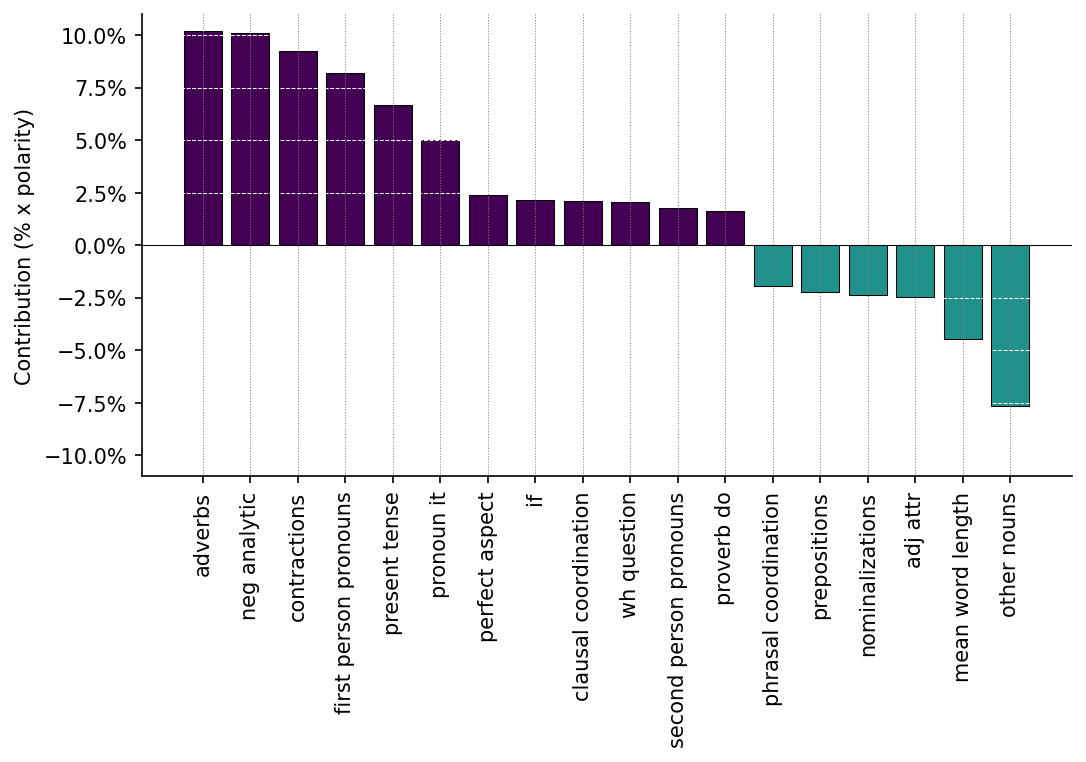

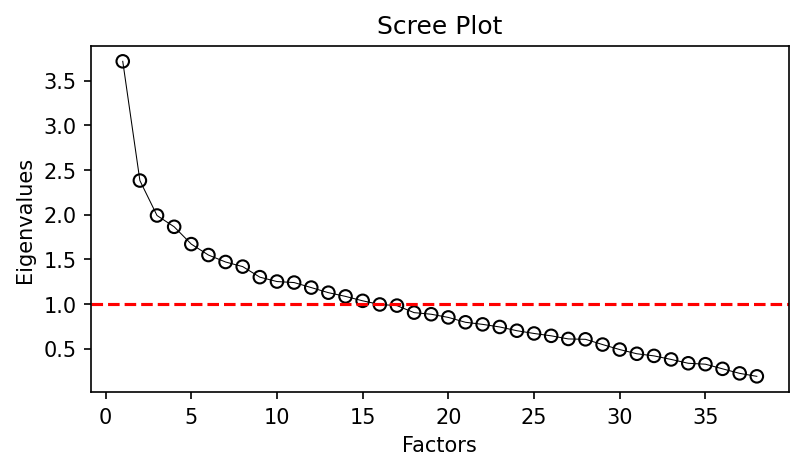

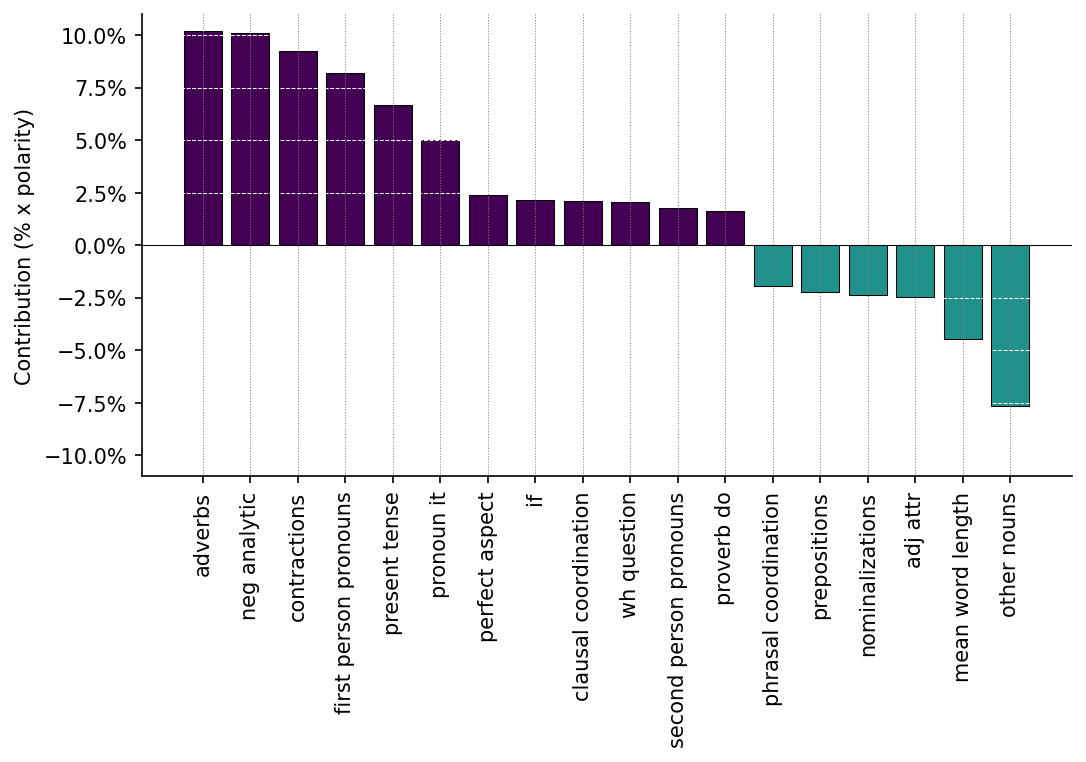

In [6]:
# Set up df for use.
df = pl.DataFrame({
    "doc_id": temp_df['doc_id'].to_list(),
    "text": temp_df['text'].to_list()
})

# Light preprocessing to strip extra whitespace.
df = df.with_columns(
    pl.col("text")
    .str.strip_chars()
    .str.replace_all(r"\s+", " ")
    .str.replace_all(r"^\s*-\s*", "") # Remove dashes at the beginning of texts.
    .str.replace_all(r"^\s*\d+\.\s*", "") # Remove numbers in 1., 2., 3. format at the beginning of the text. 
)

pipeline = pb.PybiberPipeline(model="en_core_web_sm")
features, tokens = pipeline.run(df, return_tokens=True)
features = features.with_columns(pl.col("doc_id").str.split("_").list.get(0).alias("category"))
# Full feature list can be found here: https://browndw.github.io/pybiber/feature-categories.html
print(features)

# Statistical analysis and visualization
analyzer = pb.BiberAnalyzer(features, id_column='category')

# Multi-Dimensional Analysis - see https://browndw.github.io/pybiber/biber-analyzer.html#comparison-with-bibers-original-dimensions for factor mapping
# Explanation of the factor mapping to dimensions can be found here: https://www.uni-bamberg.de/fileadmin/eng-ling/fs/Chapter_21/23DimensionsofEnglish.html
'''
Factor 1: Involved vs. Informational Production (negative to positive)
Factor 2: Narrative vs. Non-narrative Concerns (negative to positive)
Factor 3: Explicit vs. Situation-dependent Reference (negative to positive)
Factor 4: Overt Expression of Persuasion (negative to positive)
Factor 5: Abstract vs. Non-abstract Information (negative to positive)
Factor 6: On-line Informational Elaboration (negative to positive)
'''

analyzer.mda_biber()
print(analyzer.mda_summary)
print(analyzer.mda_loadings)
print(analyzer.mda_dim_scores)
print(analyzer.mda_group_means)

# Principal Component Analysis
analyzer.pca()

# Visualization options
analyzer.mdaviz_screeplot()           # Eigenvalue plot
analyzer.pcaviz_contrib()             # Feature contributions

In [7]:
print(analyzer.mda_summary)

shape: (7, 6)
┌──────────┬───────────┬───────────┬────────────┬───────────────┬──────────┐
│ Factor   ┆ F         ┆ df        ┆ PR(>F)     ┆ Signif        ┆ R2       │
│ ---      ┆ ---       ┆ ---       ┆ ---        ┆ ---           ┆ ---      │
│ str      ┆ f64       ┆ list[i64] ┆ f64        ┆ str           ┆ f64      │
╞══════════╪═══════════╪═══════════╪════════════╪═══════════════╪══════════╡
│ factor_1 ┆ 44.980895 ┆ [13, 686] ┆ 0.0        ┆ *** p < 0.001 ┆ 0.460162 │
│ factor_2 ┆ 32.911628 ┆ [13, 686] ┆ 0.0        ┆ *** p < 0.001 ┆ 0.384119 │
│ factor_3 ┆ 4.37864   ┆ [13, 686] ┆ 3.8521e-7  ┆ *** p < 0.001 ┆ 0.076619 │
│ factor_4 ┆ 11.836809 ┆ [13, 686] ┆ 0.0        ┆ *** p < 0.001 ┆ 0.183215 │
│ factor_5 ┆ 6.874677  ┆ [13, 686] ┆ 1.4437e-12 ┆ *** p < 0.001 ┆ 0.115262 │
│ factor_6 ┆ 2.89235   ┆ [13, 686] ┆ 0.00043    ┆ *** p < 0.001 ┆ 0.051963 │
│ factor_7 ┆ NaN       ┆ [13, 686] ┆ NaN        ┆ NS            ┆ NaN      │
└──────────┴───────────┴───────────┴────────────┴─────────────

In [8]:
print(analyzer.mda_loadings)

shape: (63, 8)
┌─────────────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ feature             ┆ factor_1 ┆ factor_2 ┆ factor_3 ┆ factor_4 ┆ factor_5 ┆ factor_6 ┆ factor_7 │
│ ---                 ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str                 ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═════════════════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ f_01_past_tense     ┆ -0.083   ┆ 0.895    ┆ 0.002    ┆ -0.249   ┆ -0.049   ┆ -0.052   ┆ 0.021    │
│ f_02_perfect_aspect ┆ 0.051    ┆ 0.48     ┆ 0.049    ┆ -0.016   ┆ -0.101   ┆ 0.146    ┆ 0.143    │
│ f_03_present_tense  ┆ 0.864    ┆ -0.467   ┆ -0.008   ┆ 0.229    ┆ -0.006   ┆ 0.011    ┆ 0.011    │
│ f_04_place_adverbia ┆ -0.417   ┆ -0.06    ┆ -0.492   ┆ -0.094   ┆ -0.067   ┆ -0.018   ┆ -0.023   │
│ ls                  ┆          ┆          ┆          ┆          ┆         

In [9]:
print(analyzer.mda_dim_scores)

shape: (700, 9)
┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ doc_id   ┆ doc_cat  ┆ factor_1 ┆ factor_2 ┆ factor_3 ┆ factor_4 ┆ factor_5 ┆ factor_6 ┆ factor_7 │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str      ┆ str      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 20NewsGr ┆ 20NewsGr ┆ 7.23395  ┆ -0.98374 ┆ -1.09977 ┆ 2.422518 ┆ 1.723254 ┆ 2.49338  ┆ 0.0      │
│ oups_0   ┆ oups     ┆          ┆ 2        ┆ 1        ┆          ┆          ┆          ┆          │
│ 20NewsGr ┆ 20NewsGr ┆ 33.39438 ┆ -0.86873 ┆ -2.95361 ┆ 2.257552 ┆ -1.07179 ┆ 1.998957 ┆ 0.0      │
│ oups_1   ┆ oups     ┆ 6        ┆ 3        ┆ 7        ┆          ┆ 3        ┆          ┆          │
│ 20NewsGr ┆ 20NewsGr ┆ 3.129681 ┆ 2.595713 ┆ -1.39341 ┆ -0.97118 ┆ -1.0717

In [10]:
print(analyzer.mda_group_means)

shape: (14, 8)
┌───────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┐
│ doc_cat       ┆ factor_1  ┆ factor_2  ┆ factor_3  ┆ factor_4  ┆ factor_5  ┆ factor_6  ┆ factor_7 │
│ ---           ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str           ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪══════════╡
│ 20NewsGroups  ┆ 4.760163  ┆ -0.125415 ┆ 0.163663  ┆ 0.500451  ┆ -0.086697 ┆ 0.489871  ┆ 0.0      │
│ atis          ┆ -5.652773 ┆ -1.97679  ┆ 0.310886  ┆ -0.653855 ┆ -0.713145 ┆ -0.700499 ┆ 0.0      │
│ augmentedClin ┆ -3.842215 ┆ 0.48677   ┆ 0.579486  ┆ -0.678849 ┆ 1.333195  ┆ 0.308047  ┆ 0.0      │
│ icalNotes     ┆           ┆           ┆           ┆           ┆           ┆           ┆          │
│ banking77     ┆ 12.004606 ┆ -0.775047 ┆ -1.541059 ┆ 3.528578  ┆ -0.690046 

In [11]:
print(analyzer.mda_summary.dtypes)

[String, Float64, List(Int64), Float64, String, Float64]


In [12]:
os.makedirs(f"./{OUTPUT_DIR}/", exist_ok=True)

def flatten_for_csv(df):
    # Work on a copy to avoid modifying original.
    df_flat = df.clone()
    for c, dtype in zip(df_flat.columns, df_flat.dtypes):
        if dtype == pl.List:
            # Join list elements into string with commas.
            df_flat = df_flat.with_columns(
                pl.Series(df_flat[c].name, [",".join(map(str, x)) if x is not None else "" for x in df_flat[c]])
            )
        elif dtype == pl.Struct:
            # Convert struct to string representation.
            df_flat = df_flat.with_columns(
                pl.Series(df_flat[c].name, df_flat[c].cast(pl.Utf8))
            )
    return df_flat

# Write CSV files.
flatten_for_csv(analyzer.mda_summary).write_csv(f"./{OUTPUT_DIR}/mda_summary.csv", float_precision=15)
flatten_for_csv(analyzer.mda_loadings).write_csv(f"./{OUTPUT_DIR}/mda_loadings.csv", float_precision=15)
flatten_for_csv(analyzer.mda_dim_scores).write_csv(f"./{OUTPUT_DIR}/mda_dim_scores.csv", float_precision=15)
flatten_for_csv(analyzer.mda_group_means).write_csv(f"./{OUTPUT_DIR}/mda_group_means.csv", float_precision=15)

# Write JSON files.
analyzer.mda_summary.write_json(f"./{OUTPUT_DIR}/mda_summary.json")
analyzer.mda_loadings.write_json(f"./{OUTPUT_DIR}/mda_loadings.json")
analyzer.mda_dim_scores.write_json(f"./{OUTPUT_DIR}/mda_dim_scores.json")
analyzer.mda_group_means.write_json(f"./{OUTPUT_DIR}/mda_group_means.json")
